# pca analysis

In [68]:
import os
import torch
import logging
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from datasets import load_dataset
from llm_jepa.evaluation.evaluate import load_model_and_tokenizer
from llm_jepa.evaluation.metrics import evaluate_sample
from llm_jepa.models import get_adapter

logger = logging.getLogger("llm_jepa")

In [69]:
def format_conversation(messages, tokenizer, include_assistant=False, plain=False, similarity=False):
    """Format conversation for the model."""
    if not include_assistant:
        messages = [msg for msg in messages if msg["role"] != "assistant"]
    if plain:
        if similarity:
            return messages[0]["content"]
        return messages[1]["content"] + "<|perception|>"
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def generate_response(model, tokenizer, prompt, max_length=512, max_new_tokens=128):
    """Generate a single response."""
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=max_length)
    if hasattr(model, "device"):
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            do_sample=False,
            max_new_tokens=max_new_tokens,
            return_dict_in_generate=True,
            output_hidden_states=True,
        )

    generated_tokens = outputs.sequences[0][len(inputs["input_ids"][0]):]
    response = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()
    if response.endswith("<|end|>"):
        response = response[:-7].strip()
    return response, outputs.hidden_states

In [70]:
def process_dataset_with_pca(
    input_file, original_model_name, model, tokenizer,
    max_length=512, max_new_tokens=128, spider_path="",
    max_examples=None, split_tune_untune=False, plain=False,
):
    """Process dataset and report accuracy."""
    adapter = get_adapter(original_model_name)
    dataset_name = os.path.basename(input_file)

    if input_file.endswith(".jsonl"):
        dataset = load_dataset("json", data_files=input_file)["train"]
    else:
        raise ValueError("Only JSONL files are supported")

    logger.info(f"Loaded {len(dataset)} examples from {input_file}")
    if max_examples:
        dataset = dataset.select(range(min(max_examples, len(dataset))))

    correct = []
    incorrect = []
    all_generated = []
    all_references = []
    pca_scores = []

    for idx, example in enumerate(tqdm(dataset, desc="Generating")):
        messages = example["messages"]
        full_messages = adapter.get_messages(messages)
        prompt = format_conversation(full_messages, tokenizer, plain=plain)

        generated, hidden_states = generate_response(model, tokenizer, prompt, max_length, max_new_tokens)

        is_correct = evaluate_sample(
            generated, messages, dataset_name, spider_path=spider_path,
        )

        all_generated.append(generated)
        all_references.append(messages[2]["content"])

        if split_tune_untune:
            if is_correct:
                correct.append(1)
            else:
                incorrect.append(1)
        else:
            correct.append(1 if is_correct else 0)

        pca_scores.append(compute_pca_metrics(hidden_states))

    return correct, incorrect, all_generated, all_references, pca_scores

In [71]:
def _svd_metrics(matrix):
    """Compute PC1, PC1+PC2, and effective dimensionality from a (N, D) matrix."""
    centered = matrix - matrix.mean(dim=0)
    _, s, _ = torch.linalg.svd(centered, full_matrices=False)
    s2 = s ** 2
    total = s2.sum()
    return {
        "pc1": (s2[0] / total).item(),
        "pc12": ((s2[0] + s2[1]) / total).item(),
        "eff_dim": (total ** 2 / (s2 ** 2).sum()).item(),
    }


def compute_pca_metrics(hidden_states):
    """
    Compute PCA metrics in two views from a single sequence's hidden states.

    View 1 — "across tokens": for each layer, PCA on (n_generated, hidden_dim).
      Only uses generated tokens (steps 1..T). Measures how the generation
      trajectory spreads at each layer.

    View 2 — "across layers": for each token position, PCA on (L, hidden_dim).
      Uses ALL tokens (prompt + generated). Measures how each token's
      representation evolves through the network depth.
    """
    T = len(hidden_states)       # generation steps
    L = len(hidden_states[0])    # layers (including embedding)
    prompt_len = hidden_states[0][0].shape[1]
    n_generated = T - 1
    total_tokens = prompt_len + n_generated

    # View 1: generation-only trajectories per layer
    gen_layer_trajectories = [[] for _ in range(L)]

    # View 2: all-token trajectories per position (across layers)
    token_trajectories = [[] for _ in range(total_tokens)]

    for l in range(L):
        # Prompt tokens from step 0 — only used for across-layers view
        prompt_hidden = hidden_states[0][l].squeeze(0)  # (prompt_len, hidden_dim)
        for pos in range(prompt_len):
            token_trajectories[pos].append(prompt_hidden[pos])

        # Last prompt token also seeds the generation trajectory
        gen_layer_trajectories[l].append(prompt_hidden[-1])

        # Generated tokens from steps 1..T-1
        for t in range(1, T):
            rep = hidden_states[t][l].squeeze(0).squeeze(0)  # (hidden_dim,)
            gen_layer_trajectories[l].append(rep)
            token_trajectories[prompt_len + t - 1].append(rep)

    # View 1: across tokens at each layer (generation only)
    at_pc1, at_pc12, at_eff = [], [], []
    for layer_reps in gen_layer_trajectories:
        m = _svd_metrics(torch.stack(layer_reps).float())
        at_pc1.append(m["pc1"])
        at_pc12.append(m["pc12"])
        at_eff.append(m["eff_dim"])

    # View 2: across layers at each token position (all tokens)
    al_pc1, al_pc12, al_eff = [], [], []
    for token_reps in token_trajectories:
        m = _svd_metrics(torch.stack(token_reps).float())
        al_pc1.append(m["pc1"])
        al_pc12.append(m["pc12"])
        al_eff.append(m["eff_dim"])

    return {
        "across_tokens": {
            "pc1_ratio": at_pc1,
            "pc12_ratio": at_pc12,
            "eff_dim": at_eff,
        },
        "across_layers": {
            "pc1_ratio": al_pc1,
            "pc12_ratio": al_pc12,
            "eff_dim": al_eff,
        },
        "prompt_len": prompt_len,
    }

# Run analysis

In [72]:
original_model = "meta-llama/Llama-3.2-1B-Instruct"
input_file = "/home/jay/repos/llm-jepa/datasets/synth_test.jsonl"

models_to_compare = {
    "NTP": "/home/jay/repos/llm-jepa/output-exp1-regular",
    "STP": "/home/jay/repos/llm-jepa/output-exp1-stp",
}

max_examples = 5  # bump this up once you've verified it works

In [73]:
from transformers import AutoModelForCausalLM, AutoTokenizer

def run_pca_analysis(model_path, original_model_name, input_file, max_examples=50,
                     max_length=128, max_new_tokens=128):
    """Load a model, run PCA analysis on the dataset, free GPU memory, return scores."""
    print(f"Loading {model_path}...")

    # Load tokenizer from base model — checkpoint tokenizer_config.json is broken
    # (has "backend" instead of "tokenizer_class")
    tokenizer = AutoTokenizer.from_pretrained(original_model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_path,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        trust_remote_code=True,
        low_cpu_mem_usage=True,
    )
    model.eval()

    _, _, _, _, pca_scores = process_dataset_with_pca(
        input_file=input_file,
        original_model_name=original_model_name,
        model=model,
        tokenizer=tokenizer,
        max_length=max_length,
        max_new_tokens=max_new_tokens,
        max_examples=max_examples,
    )

    del model, tokenizer
    torch.cuda.empty_cache()

    return pca_scores

In [74]:
scores_by_model = {}
for label, model_path in models_to_compare.items():
    scores_by_model[label] = run_pca_analysis(
        model_path, original_model, input_file, max_examples=max_examples,
    )

Loading /home/jay/repos/llm-jepa/output-exp1-regular...


Generating: 100%|██████████| 5/5 [00:03<00:00,  1.50it/s]


Loading /home/jay/repos/llm-jepa/output-exp1-stp...


Generating: 100%|██████████| 5/5 [00:01<00:00,  4.22it/s]


In [75]:
for label, scores in scores_by_model.items():
    at_data = np.array([s["across_tokens"]["pc1_ratio"] for s in scores])
    al_data = [s["across_layers"]["pc1_ratio"] for s in scores]
    al_mean = np.mean([np.mean(seq) for seq in al_data])
    print(f"{label}: {len(scores)} sequences")
    print(f"  across-tokens  mean PC1 ratio: {at_data.mean():.4f}")
    print(f"  across-layers  mean PC1 ratio: {al_mean:.4f}")

NTP: 5 sequences
  across-tokens  mean PC1 ratio: 0.2316
  across-layers  mean PC1 ratio: 0.9663
STP: 5 sequences
  across-tokens  mean PC1 ratio: 0.2018
  across-layers  mean PC1 ratio: 0.9667


metric explanations:
pca_ratio - the ratio of the direction with the most variance. High means it explain a lot of movement, or straightness. Low means variance is spread across dimensions.
pc1 + pc2 ratio - ratio for top two direction. Tells us if the trajactory is planar
effective dimensionality - just that.

# Plotting

`scores_by_model` is a dict mapping a label to a list of per-sequence score dicts.
Add entries for each model you want to compare, e.g. `{"base": pca_scores, "stp": stp_scores}`.

In [76]:
def plot_layer_curves(scores_by_model, view="across_tokens", figsize=(15, 4)):
    """
    Layer-wise mean ± std for all three metrics.
    One subplot per metric, one line per model.
    """
    metrics = ["pc1_ratio", "pc12_ratio", "eff_dim"]
    titles  = ["PC1 Ratio", "PC1+PC2 Ratio", "Effective Dimensionality"]
    colors  = ["steelblue", "coral", "seagreen", "mediumpurple"]

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    for ax, metric, title in zip(axes, metrics, titles):
        for (model_name, scores), color in zip(scores_by_model.items(), colors):
            data = np.array([s[view][metric] for s in scores])
            mean = data.mean(axis=0)
            std  = data.std(axis=0)
            x = np.arange(data.shape[1])

            ax.plot(x, mean, label=model_name, color=color)
            ax.fill_between(x, mean - std, mean + std, alpha=0.2, color=color)

        ax.set_xlabel("Layer")
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Variance fraction")
    axes[2].set_ylabel("Dimensions")
    plt.suptitle(f"PCA Metrics — {view.replace('_', ' ')}", fontsize=13)
    plt.tight_layout()
    plt.show()


def _truncate_across_layers(scores_by_model, metric):
    """Truncate variable-length across-layers data to common length using 10th percentile."""
    all_lens = [
        len(s["across_layers"][metric])
        for scores in scores_by_model.values()
        for s in scores
    ]
    # Use 10th percentile instead of min so one short sequence doesn't ruin everything
    cutoff = int(np.percentile(all_lens, 10))
    cutoff = max(cutoff, min(all_lens))  # but never exceed the actual min
    return cutoff


def plot_across_layers_curves(scores_by_model, figsize=(15, 4)):
    """
    Token-position-wise mean ± std for across-layers PCA metrics.
    x-axis = token position in the full sequence (prompt + generated).
    """
    metrics = ["pc1_ratio", "pc12_ratio", "eff_dim"]
    titles  = ["PC1 Ratio", "PC1+PC2 Ratio", "Effective Dimensionality"]
    colors  = ["steelblue", "coral", "seagreen", "mediumpurple"]

    cutoff = _truncate_across_layers(scores_by_model, "pc1_ratio")

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    for ax, metric, title in zip(axes, metrics, titles):
        for (model_name, scores), color in zip(scores_by_model.items(), colors):
            data = np.array([s["across_layers"][metric][:cutoff] for s in scores
                             if len(s["across_layers"][metric]) >= cutoff])
            mean = data.mean(axis=0)
            std  = data.std(axis=0)
            x = np.arange(cutoff)

            ax.plot(x, mean, label=model_name, color=color)
            ax.fill_between(x, mean - std, mean + std, alpha=0.2, color=color)

            # Mark mean prompt boundary
            prompt_lens = [s["prompt_len"] for s in scores]
            mean_prompt = int(np.mean(prompt_lens))
            ax.axvline(mean_prompt, color="gray", linestyle="--", alpha=0.5)

        ax.set_xlabel("Token position")
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Variance fraction")
    axes[2].set_ylabel("Dimensions")
    plt.suptitle("PCA Metrics — across layers (per token through network)", fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_gap(scores_by_model, view="across_tokens", figsize=(7, 4)):
    """PC1+PC2 minus PC1 — the curvature signal."""
    colors = ["steelblue", "coral", "seagreen", "mediumpurple"]
    fig, ax = plt.subplots(figsize=figsize)

    if view == "across_layers":
        cutoff = _truncate_across_layers(scores_by_model, "pc1_ratio")
        for (model_name, scores), color in zip(scores_by_model.items(), colors):
            valid = [s for s in scores if len(s[view]["pc1_ratio"]) >= cutoff]
            pc1  = np.array([s[view]["pc1_ratio"][:cutoff]  for s in valid])
            pc12 = np.array([s[view]["pc12_ratio"][:cutoff] for s in valid])
            gap  = (pc12 - pc1).mean(axis=0)
            ax.plot(np.arange(cutoff), gap, label=model_name, color=color)
    else:
        for (model_name, scores), color in zip(scores_by_model.items(), colors):
            pc1  = np.array([s[view]["pc1_ratio"]  for s in scores])
            pc12 = np.array([s[view]["pc12_ratio"] for s in scores])
            gap  = (pc12 - pc1).mean(axis=0)
            ax.plot(np.arange(pc1.shape[1]), gap, label=model_name, color=color)

    xlabel = "Layer" if view == "across_tokens" else "Token position"
    ax.set_xlabel(xlabel)
    ax.set_ylabel("PC2 contribution (PC1+PC2 − PC1)")
    ax.set_title(f"Curvature Signal — {view.replace('_', ' ')}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

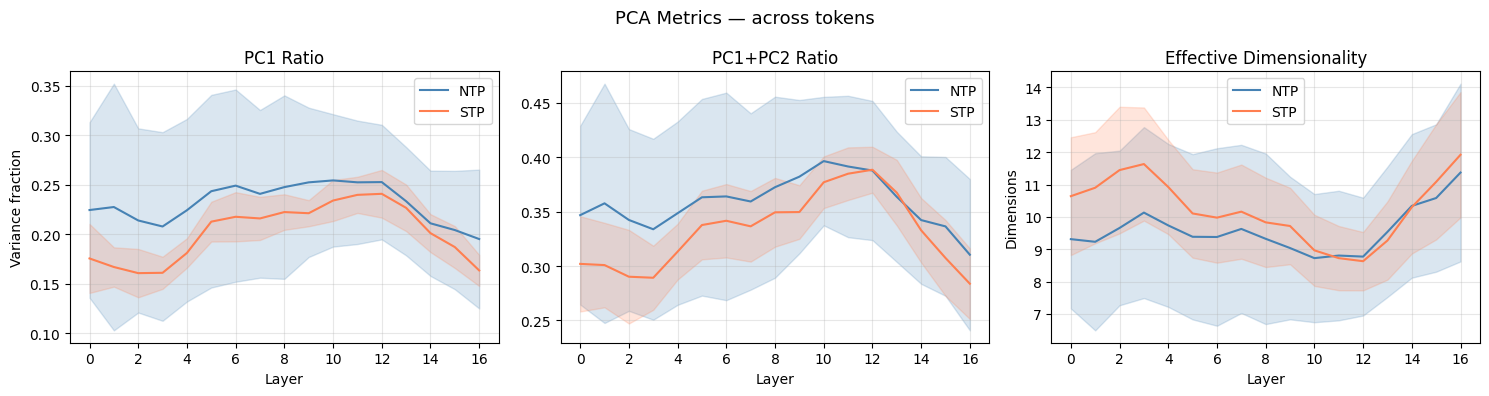

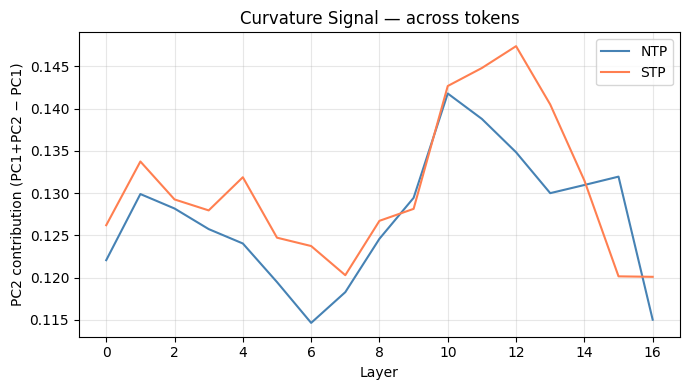

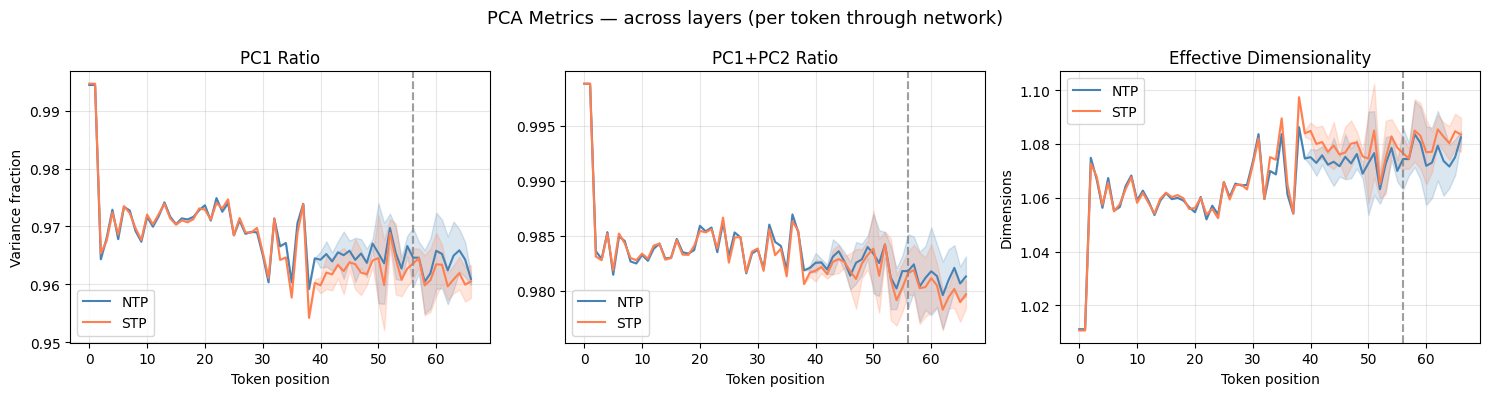

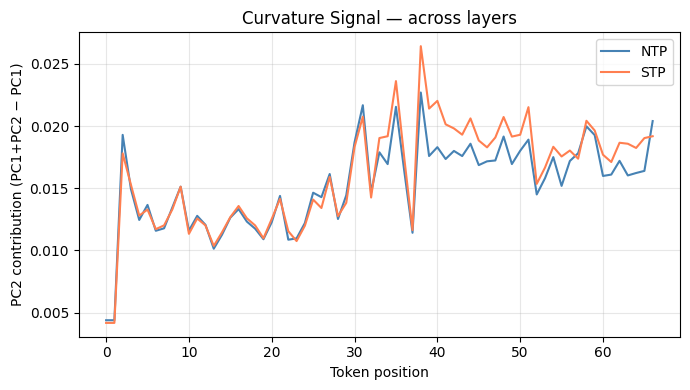

In [77]:
# Original view: across tokens at each layer
plot_layer_curves(scores_by_model, view="across_tokens")
plot_gap(scores_by_model, view="across_tokens")

# New view: across layers at each token position
plot_across_layers_curves(scores_by_model)
plot_gap(scores_by_model, view="across_layers")

Finding: the pca for both is pretty low, meaning there is a lot of multidimensional noise that makes it challenging to find the actual trajectory component. Interestingly though, STP has much less variance in it's variance fraction, which would seem to suggest that across multiple samples, it's component is much more consistent...this is interesting.